Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.


Seasonal variations can influence different aspects of agricultural activities and performance. Understanding seasonal patterns through data analytics can help stakeholders:  Understand variations in agricultural performance   Identify important seasonal trends   Compare performance across different periods   Understand changing environmental conditions   Examine differences in resource usage   Identify areas requiring further investigation   Support evidence-based agricultural planning  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 4000
Columns: 28


In [ ]:

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
missing = df.isnull().sum()

print(missing)

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print(df['Season'].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


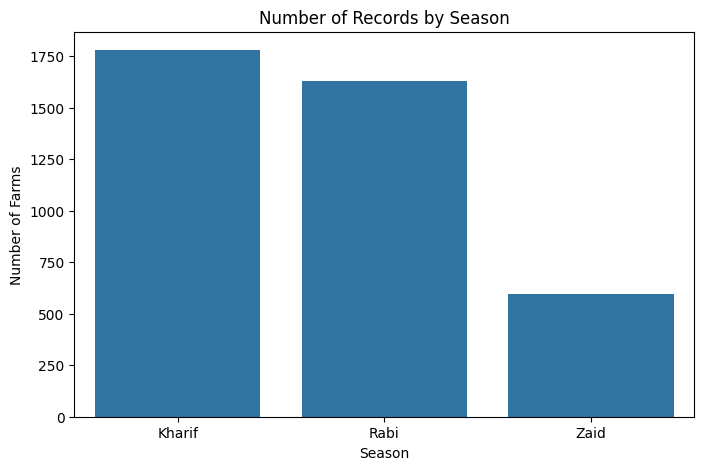

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()

In [ ]:
season_performance = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
})

season_performance.round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,,
Kharif,5.64,46.31,710719.06,531804.41,178914.65
Rabi,5.08,41.49,601526.05,513836.58,87689.47
Zaid,4.67,38.89,519171.90,543976.73,-24804.82


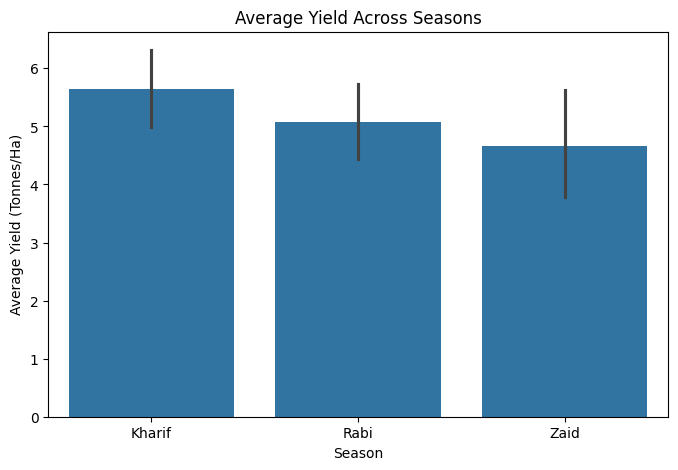

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

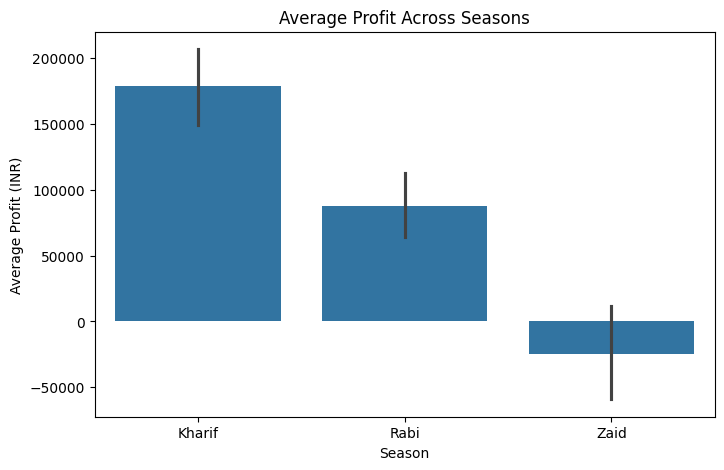

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

In [ ]:
financial = df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR'
]].mean()

financial.round(2)

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


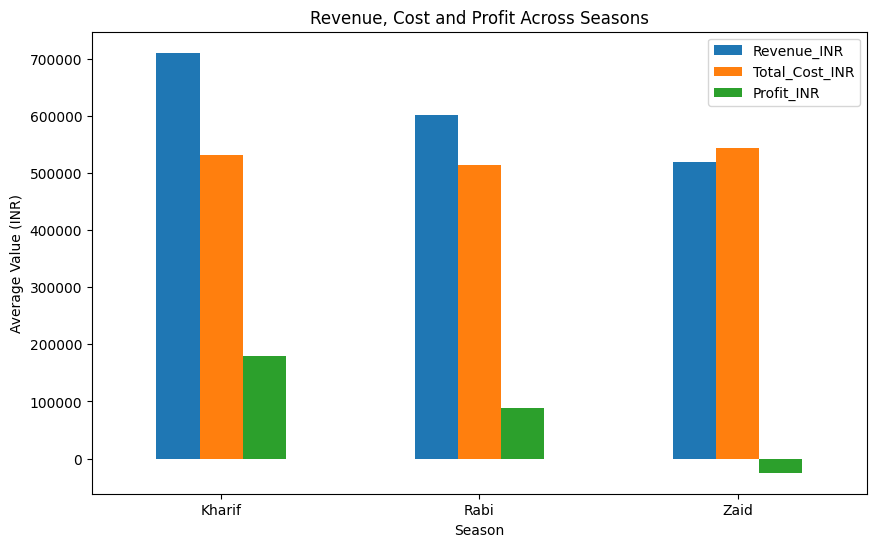

In [ ]:
financial.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Revenue, Cost and Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value (INR)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
environment = df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day'
]].mean()

environment.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.08,28.45,71.81,6.79
Rabi,436.00,23.49,57.89,7.59
Zaid,299.42,31.04,52.01,8.18


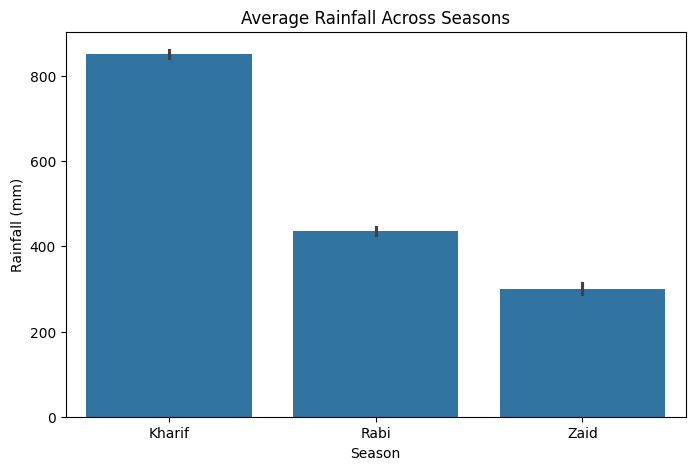

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Rainfall_mm'
)

plt.title("Average Rainfall Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.show()

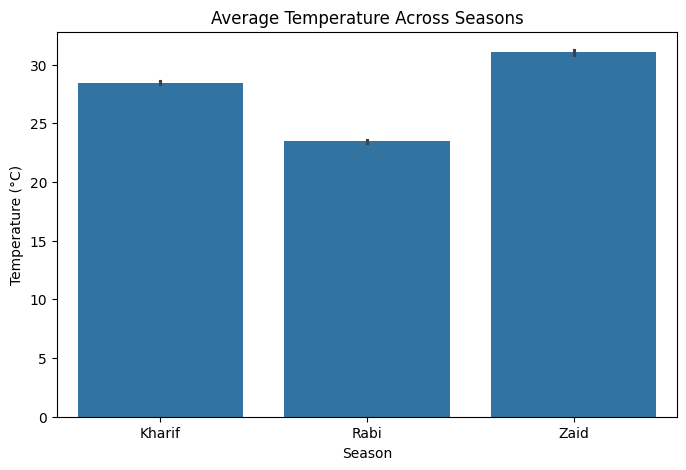

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title("Average Temperature Across Seasons")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()

In [ ]:
soil = df.groupby('Season')[[
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha'
]].mean()

soil.round(2)

,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,
Kharif,6.73,31.20,120.02,58.10,105.30
Rabi,6.67,24.05,120.40,57.31,103.93
Zaid,6.69,19.17,120.53,58.13,105.42


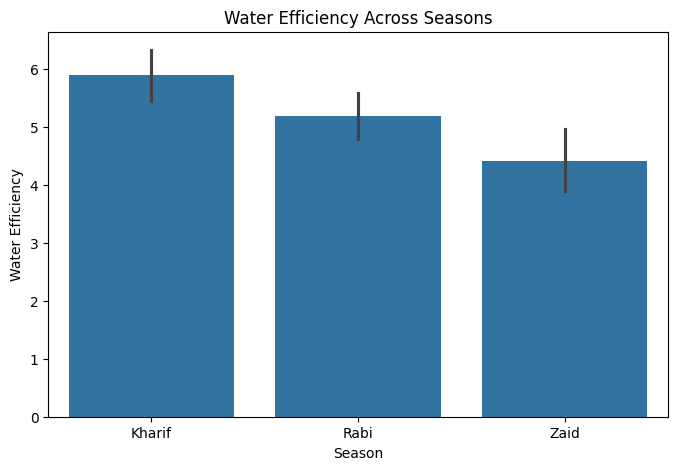

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.show()

In [ ]:
irrigation = pd.crosstab(
    df['Season'],
    df['Irrigation_Method']
)

irrigation

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


In [ ]:
crop_performance = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
)

crop_performance.round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Crop,,,
Sugarcane,46.94,392.41,817187.99
Chilli,1.54,12.38,750878.34
Cotton,1.23,9.40,124546.92
Groundnut,1.32,9.66,44858.12
Pulses,0.92,7.40,-4238.05
Maize,2.72,21.78,-83978.33
Rice,2.44,19.29,-102213.50
Wheat,2.11,16.85,-123398.34


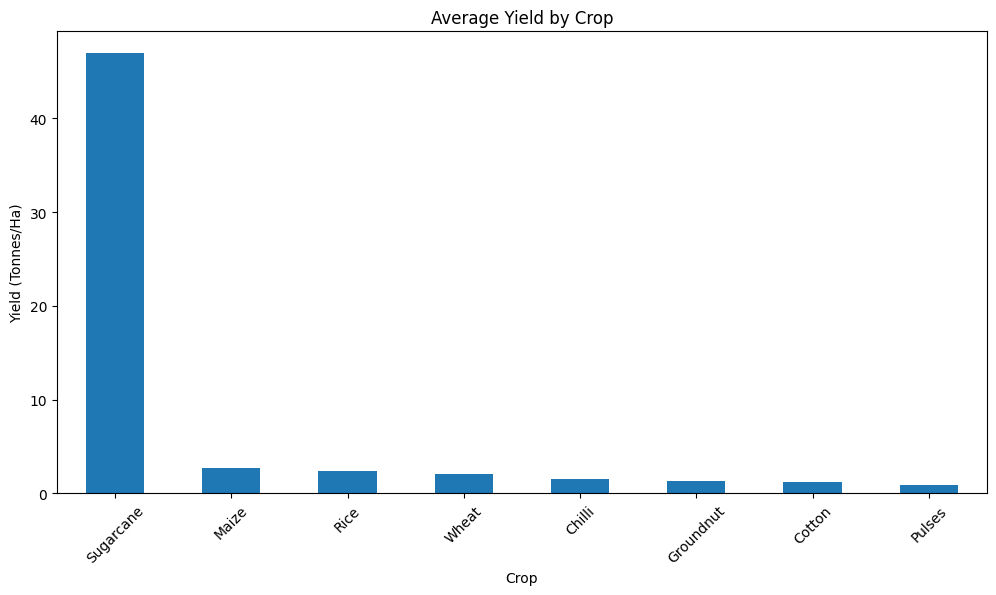

In [ ]:
plt.figure(figsize=(12,6))

crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

crop_yield.plot(kind='bar')

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

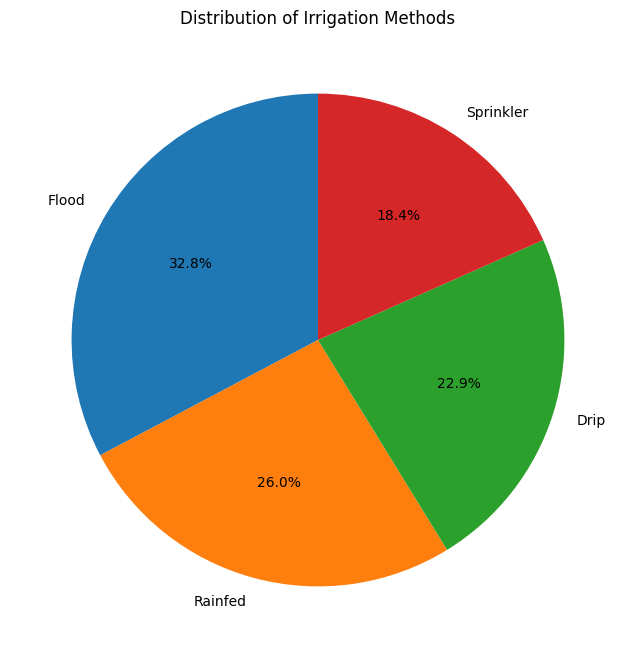

In [ ]:
irrigation_counts = df['Irrigation_Method'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    irrigation_counts.values,
    labels=irrigation_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Irrigation Methods")
plt.show()

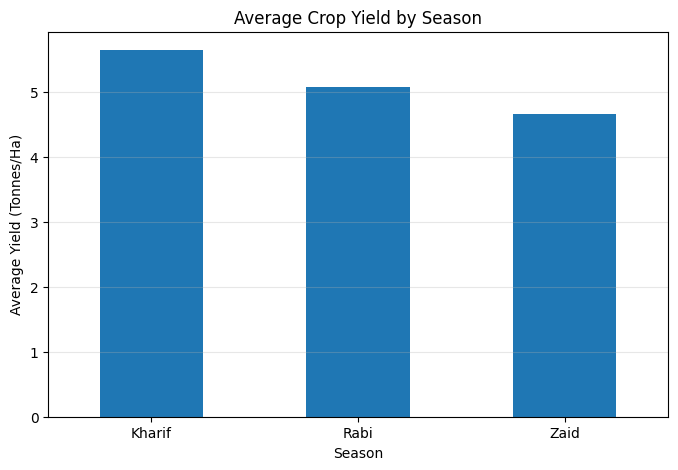

In [ ]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

plt.figure(figsize=(8, 5))

season_yield.plot(kind='bar')

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

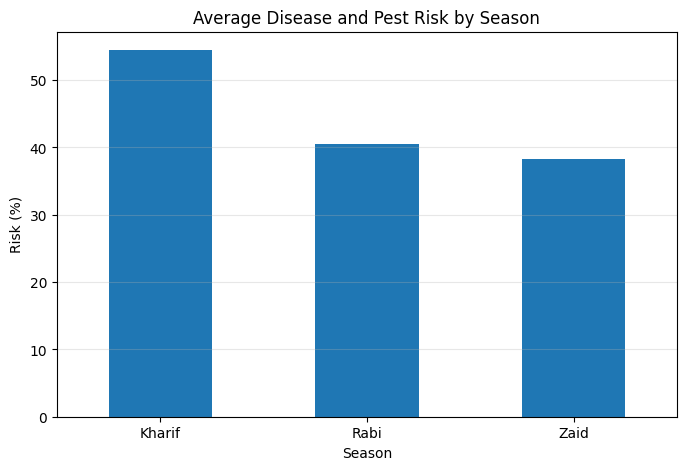

In [ ]:
season_risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()

plt.figure(figsize=(8, 5))

season_risk.plot(kind='bar')

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()

print(risk.round(2))

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


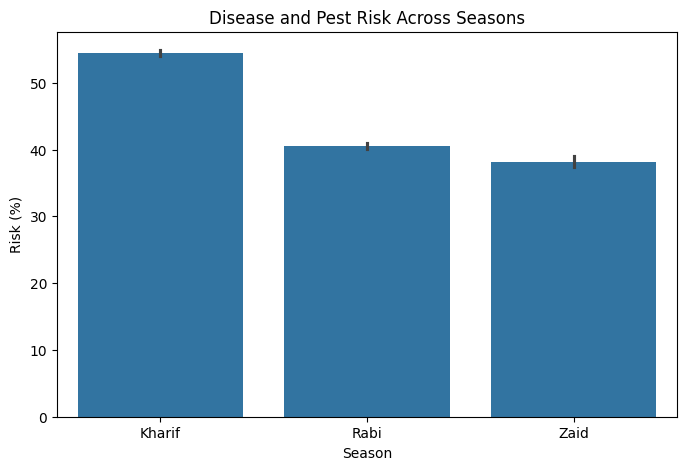

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.show()

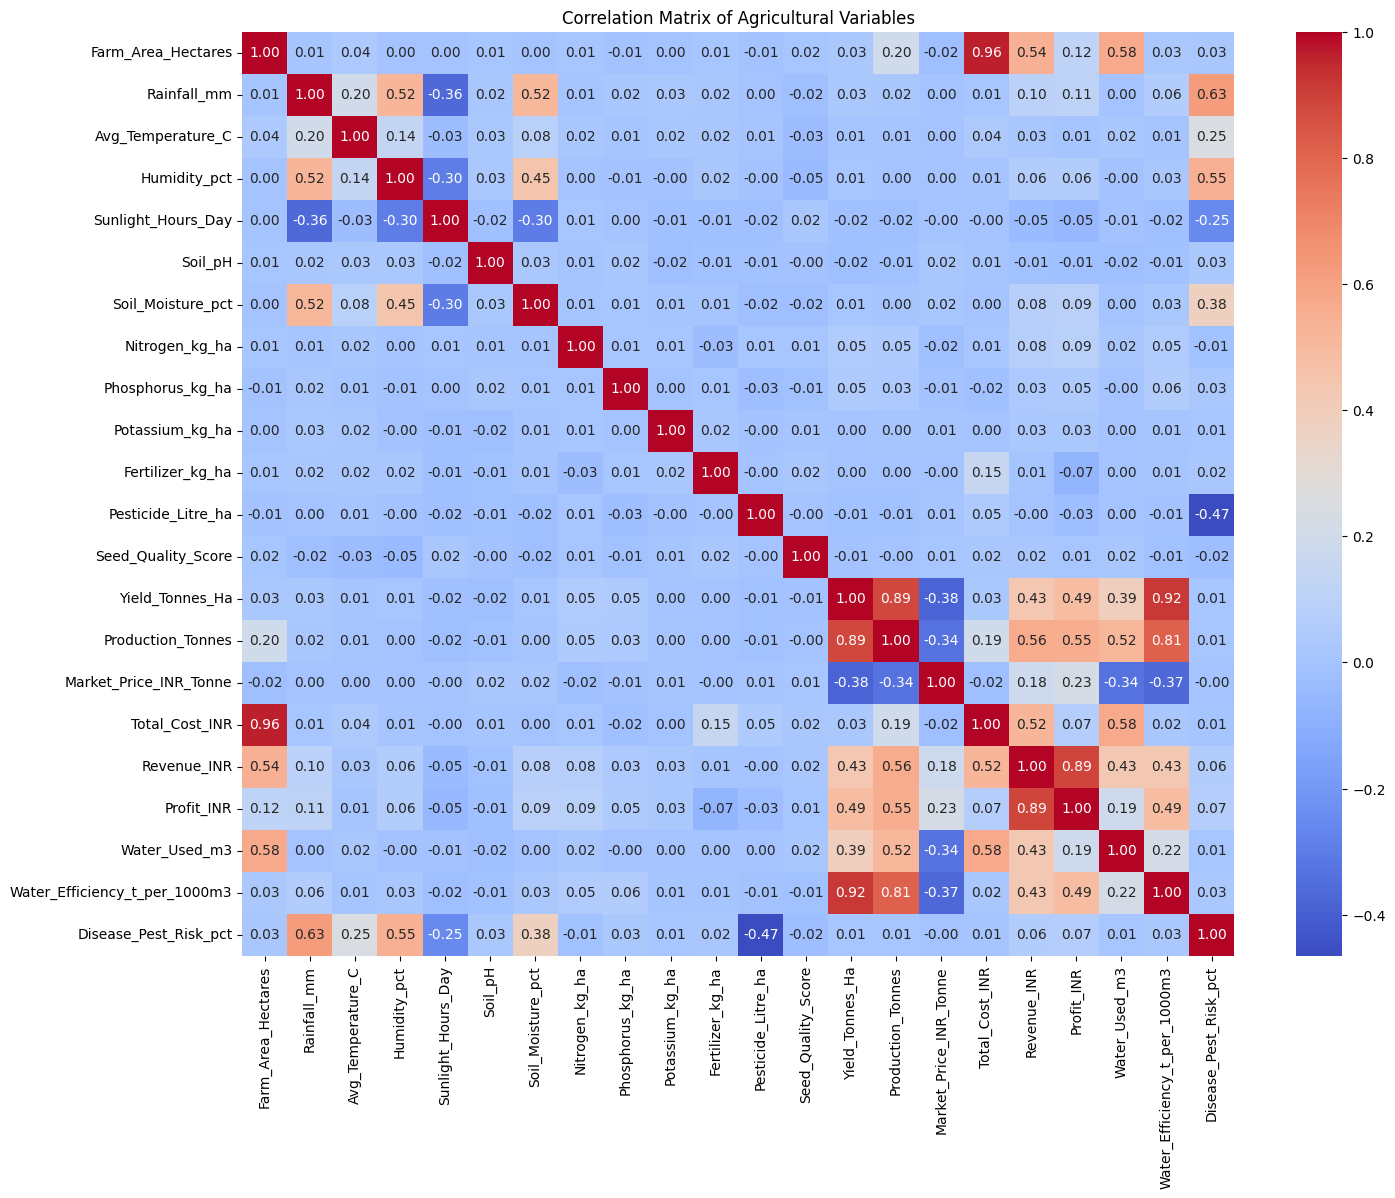

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.show()

In [ ]:
yield_corr = correlation[
    'Yield_Tonnes_Ha'
].sort_values(ascending=False)

print(yield_corr)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Farm_Area_Hectares               0.030188
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
profit_corr = correlation[
    'Profit_INR'
].sort_values(ascending=False)

print(profit_corr)

Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Yield_Tonnes_Ha                  0.489822
Water_Efficiency_t_per_1000m3    0.489487
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.108104
Soil_Moisture_pct                0.091757
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


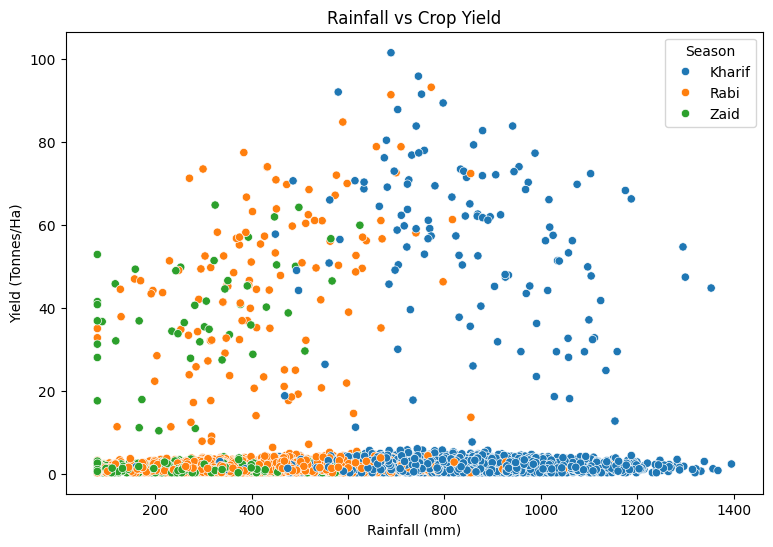

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

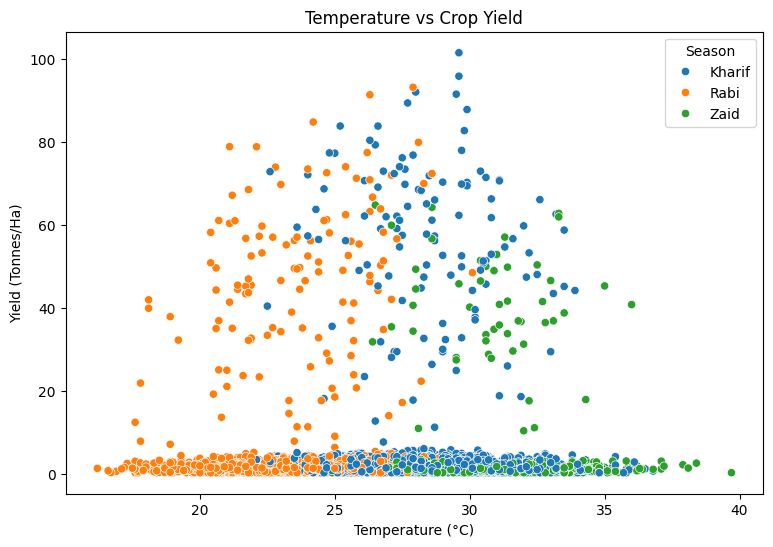

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

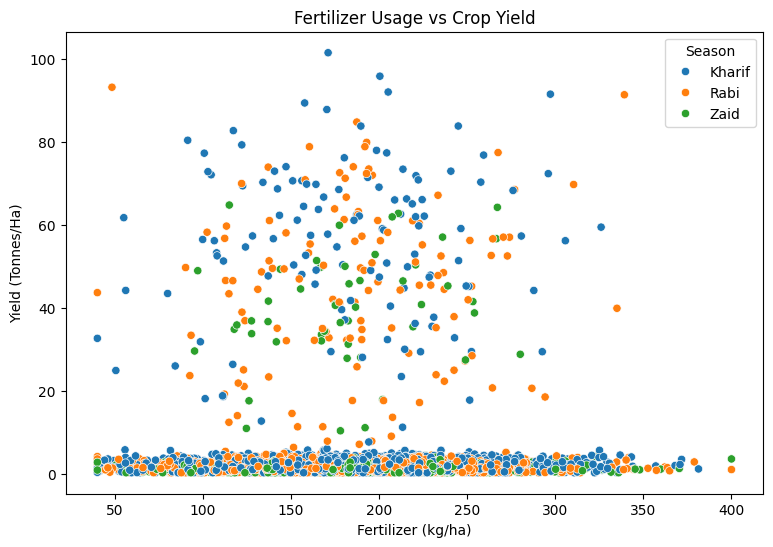

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

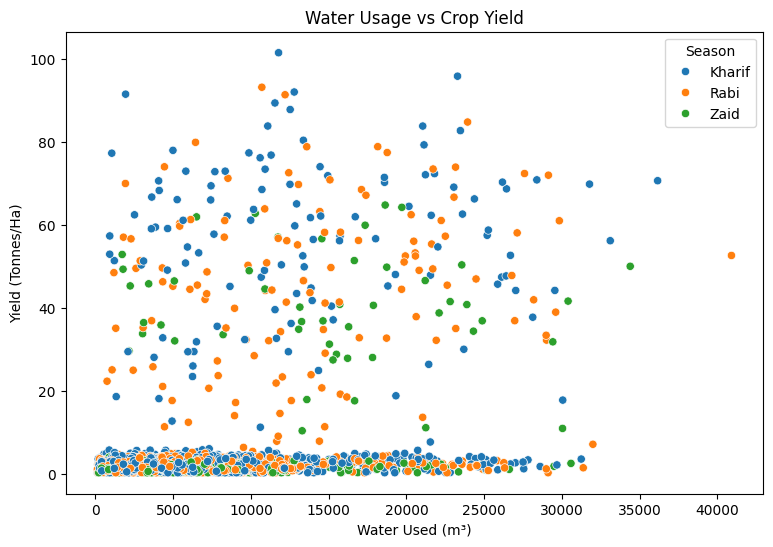

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

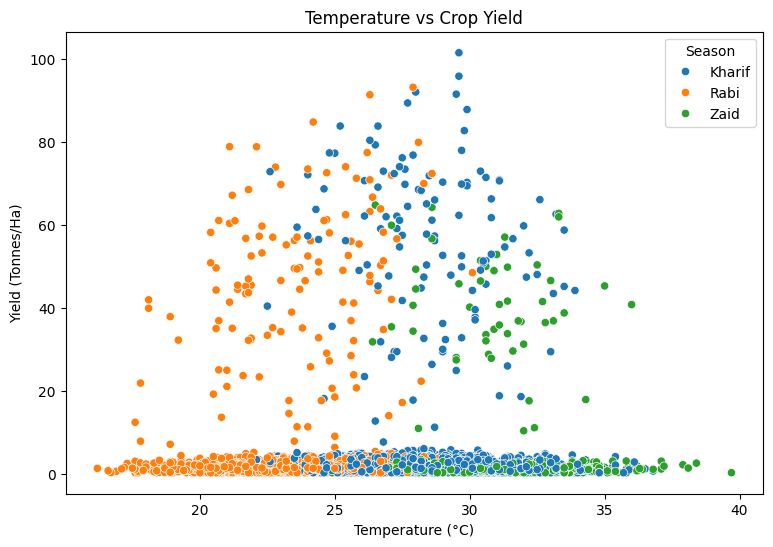

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [ ]:
season_summary = df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
)

season_summary.round(2)

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Pest_Risk
Season,,,,,,,,
Kharif,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


In [ ]:
print(
    "Highest average yield:",
    season_summary['Average_Yield'].idxmax()
)

print(
    "Highest average profit:",
    season_summary['Average_Profit'].idxmax()
)

print(
    "Highest water efficiency:",
    season_summary['Average_Water_Efficiency'].idxmax()
)

print(
    "Lowest pest/disease risk:",
    season_summary['Average_Pest_Risk'].idxmin()
)

Highest average yield: Kharif
Highest average profit: Kharif
Highest water efficiency: Kharif
Lowest pest/disease risk: Zaid


In [ ]:
best_crop = df.groupby('Crop')['Profit_INR'].mean().idxmax()

print("Crop with highest average profit:", best_crop)

Crop with highest average profit: Sugarcane


In [ ]:
state_summary = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
)

state_summary.round(2)

,Yield_Tonnes_Ha,Profit_INR
State,,
Punjab,6.12,136025.64
Maharashtra,5.03,135428.86
Karnataka,5.73,119422.34
Tamil Nadu,4.90,117744.75
Gujarat,5.70,117568.24
Telangana,5.08,108829.62
Madhya Pradesh,5.03,86840.76
Andhra Pradesh,4.65,73453.53


In [ ]:
Q1 = df['Profit_INR'].quantile(0.25)
Q3 = df['Profit_INR'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Profit_INR'] < lower) |
    (df['Profit_INR'] > upper)
]

print("Number of profit outliers:", len(outliers))

Number of profit outliers: 404


In [ ]:
final_summary = df.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
)

final_summary.round(2)

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Pest_Risk
Season,,,,,,,,,
Kharif,1779,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,1627,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,594,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


Kharif → Best overall performance
Rabi → Moderate performance
Zaid → Lowest economic performance

In [ ]:
state_season = df.groupby(['State', 'Season']).agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

state_season

Average_Yield  Average_Profit
State          Season                               
Andhra Pradesh Kharif           5.69       169315.52
               Rabi             3.49        26315.71
               Zaid             4.48       -84084.87
Gujarat        Kharif           6.34       217051.33
               Rabi             5.52        82846.20
               Zaid             4.10      -106929.61
Karnataka      Kharif           6.52       201226.21
               Rabi             4.61        70952.61
               Zaid             6.62        23310.91
Madhya Pradesh Kharif           6.00       134242.40
               Rabi             3.80        61576.26
               Zaid             5.54          209.70
Maharashtra    Kharif           5.45       168801.05
               Rabi             5.50       159581.50
               Zaid             2.29       -40597.60
Punjab         Kharif           4.10       133779.10
               Rabi             8.61       169294.52
               Zaid             5.91        62109.69
Tamil Nadu     Kharif           5.52       211303.96
               Rabi             4.56        70456.86
               Zaid             4.10       -15175.20
Telangana      Kharif           5.57       199668.38
               Rabi             4.83        62824.60
               Zaid             4.28       -34620.78

In [ ]:
crop_season = df.groupby(['Crop', 'Season']).agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

crop_season

Average_Yield  Average_Profit
Crop      Season                               
Chilli    Kharif           1.73       954380.42
          Rabi             1.46       638572.50
          Zaid             1.18       448659.09
Cotton    Kharif           1.37       216999.55
          Rabi             1.19       107343.59
          Zaid             0.95       -53925.34
Groundnut Kharif           1.48       108265.44
          Rabi             1.22        10416.54
          Zaid             1.04       -68872.50
Maize     Kharif           2.97       -39332.67
          Rabi             2.61       -89133.40
          Zaid             2.30      -194049.17
Pulses    Kharif           1.04        43338.90
          Rabi             0.87       -14309.14
          Zaid             0.65      -139227.81
Rice      Kharif           2.71       -64903.40
          Rabi             2.33       -98427.87
          Zaid             1.90      -227239.34
Sugarcane Kharif          53.46      1000790.81
          Rabi            43.94       731612.86
          Zaid            38.42       583635.80
Wheat     Kharif           2.26      -105871.87
          Rabi             2.06      -119954.57
          Zaid             1.75      -193208.95

1. Kharif performs best overall. It has the highest average yield (5.64 tonnes/ha) and profit (₹178,915). Rabi has lower yield (5.08) and profit (₹87,689), while Zaid has the lowest yield (4.67) and an average loss of ₹24,805.
2. Kharif generally has higher rainfall, soil moisture, yield and profit. Rabi has moderate rainfall and performance. Zaid has low rainfall, high temperature and low soil moisture, and generally performs worst economically.
3. Rainfall, temperature, humidity, sunlight, soil moisture, yield, production, revenue, profit, water usage, water efficiency and pest/disease risk all change noticeably between seasons.

4. Farming conditions and resource requirements differ. Kharif has higher rainfall and soil moisture, while Zaid relies more on water despite having lower rainfall. Crop performance also changes between seasons.
5. Yes. Zaid uses the most water on average (6,420 m³) but has the lowest water efficiency (4.41). Kharif uses about 6,102 m³ and has the highest efficiency (5.89).
6. Yes. Yield is strongly related to water efficiency (correlation ≈ 0.92). Seasonal rainfall and soil moisture also differ substantially and are associated with different performance levels. However, rainfall alone has only a weak overall correlation with yield (≈ 0.03), so yield depends on several factors together.

Kharif has the highest revenue (~₹7.11 lakh) and profit (~₹1.79 lakh). Rabi has ~₹6.02 lakh revenue and ~₹0.88 lakh profit. Zaid has ~₹5.19 lakh revenue but an average loss of ~₹24,805.

Mostly yes, but not everywhere. Kharif is the highest-profit season in most states, while Zaid is often the weakest. However, there are exceptions—for example, Punjab has much higher Rabi yield than Kharif, and Karnataka has high Zaid yield.

Conclusion

The analysis shows that agricultural performance varies considerably across seasons. Kharif is the best-performing season, with the highest average yield and profit. Rabi shows moderate performance, while Zaid has the weakest economic performance and records an average loss. The differences are associated with variations in rainfall, temperature, soil moisture, water usage and resource efficiency. Therefore, seasonal conditions should be considered when selecting crops, planning irrigation and allocating agricultural resources.
